# Math Concepts for Neural Networks 

This notebook builds *the minimum math intuition* you need for backprop and training.

**Goal:** you can compute (and reason about) gradients by hand for a single neuron, and you can interpret them.


## Setup

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


## 1) Scalars, vectors, matrices: shapes that matter

Neural nets are just repeated applications of:
- **weighted sums** (dot products / matrix multiplies)
- **nonlinearities** (e.g., sigmoid, ReLU)
- **loss** (a scalar that we minimize)

The main skill: keep track of **shapes**.


In [8]:
a = 1

In [9]:
id(a)

11755688

In [10]:
# memory address of a
print(hex(id(a)))

0xb360a8


In [12]:
# memory required to store a (in bytes / bits)
import sys
print("Memory required to store a:", sys.getsizeof(a), "bytes")

Memory required to store a: 28 bytes


In [26]:
m = np.array([1.0])

print("Memory required to store m:", sys.getsizeof(m), "bytes")

Memory required to store m: 120 bytes


In [30]:
m = np.array([1.0, 2.0, ])

# Memory required to store m (array with 2 elements) - after the first element, each element takes additional memory of 8 bytes (for float64)
print("Memory required to store m:", sys.getsizeof(m), "bytes")

Memory required to store m: 128 bytes


In [32]:
# Scalar
a = 3.0

# Vector (shape: (d,))
x = np.array([1.0, 2.0, -1.0])

# Matrix (shape: (m, d))
W = np.array([
    [0.2, -0.1, 0.4],
    [0.0,  0.3, -0.2]
])

b = np.array([0.1, -0.3])  # (m,)

print("a:", a, "shape:", np.shape(a))
print("x:", x, "shape:", x.shape)
print("W:\n", W, "shape:", W.shape)
print("b:", b, "shape:", b.shape)


a: 3.0 shape: ()
x: [ 1.  2. -1.] shape: (3,)
W:
 [[ 0.2 -0.1  0.4]
 [ 0.   0.3 -0.2]] shape: (2, 3)
b: [ 0.1 -0.3] shape: (2,)


In [33]:
# Linear layer: z = W x + b  -> shape (m,)
z = W @ x + b
print("\nz = W @ x + b:", z, "shape:", z.shape)



z = W @ x + b: [-0.3  0.5] shape: (2,)


### Exercise
Change `x` to a different length and watch how it breaks. Fix it by updating `W`.


## 2) Dot product = weighted sum (and similarity)

For vectors `w` and `x`, the dot product `w·x = Σ w_i x_i`.

In a neuron, this is the **pre-activation** before adding bias and applying activation.


In [34]:
w = np.array([0.5, -1.0, 2.0])
x = np.array([1.5, 0.2, -0.3])

dot = w @ x
manual = (w[0]*x[0]) + (w[1]*x[1]) + (w[2]*x[2])

print("w:", w)
print("x:", x)
print("w @ x:", dot)
print("manual:", manual)


w: [ 0.5 -1.   2. ]
x: [ 1.5  0.2 -0.3]
w @ x: -0.04999999999999993
manual: -0.04999999999999993


## 3) Key functions: sigmoid and ReLU

You should know their shapes and derivatives.

- Sigmoid: `σ(z) = 1/(1+e^{-z})`, derivative: `σ(z)(1-σ(z))`
- ReLU: `max(0,z)`, derivative: `1` if `z>0` else `0`


In [36]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

In [37]:
def d_sigmoid_from_sig(sig):
    # If sigmoid(z) = sig, derivative is sig*(1-sig)
    return sig * (1.0 - sig)

In [38]:
def relu(z):
    return np.maximum(0.0, z)

In [39]:
def d_relu(z):
    return (z > 0).astype(float)

In [41]:
zs = np.linspace(-8, 8, 401)
print(zs)

[-8.   -7.96 -7.92 -7.88 -7.84 -7.8  -7.76 -7.72 -7.68 -7.64 -7.6  -7.56
 -7.52 -7.48 -7.44 -7.4  -7.36 -7.32 -7.28 -7.24 -7.2  -7.16 -7.12 -7.08
 -7.04 -7.   -6.96 -6.92 -6.88 -6.84 -6.8  -6.76 -6.72 -6.68 -6.64 -6.6
 -6.56 -6.52 -6.48 -6.44 -6.4  -6.36 -6.32 -6.28 -6.24 -6.2  -6.16 -6.12
 -6.08 -6.04 -6.   -5.96 -5.92 -5.88 -5.84 -5.8  -5.76 -5.72 -5.68 -5.64
 -5.6  -5.56 -5.52 -5.48 -5.44 -5.4  -5.36 -5.32 -5.28 -5.24 -5.2  -5.16
 -5.12 -5.08 -5.04 -5.   -4.96 -4.92 -4.88 -4.84 -4.8  -4.76 -4.72 -4.68
 -4.64 -4.6  -4.56 -4.52 -4.48 -4.44 -4.4  -4.36 -4.32 -4.28 -4.24 -4.2
 -4.16 -4.12 -4.08 -4.04 -4.   -3.96 -3.92 -3.88 -3.84 -3.8  -3.76 -3.72
 -3.68 -3.64 -3.6  -3.56 -3.52 -3.48 -3.44 -3.4  -3.36 -3.32 -3.28 -3.24
 -3.2  -3.16 -3.12 -3.08 -3.04 -3.   -2.96 -2.92 -2.88 -2.84 -2.8  -2.76
 -2.72 -2.68 -2.64 -2.6  -2.56 -2.52 -2.48 -2.44 -2.4  -2.36 -2.32 -2.28
 -2.24 -2.2  -2.16 -2.12 -2.08 -2.04 -2.   -1.96 -1.92 -1.88 -1.84 -1.8
 -1.76 -1.72 -1.68 -1.64 -1.6  -1.56 -1.52 -1.48 -1.44

In [43]:
sig = sigmoid(zs)
sig[0:10]

array([0.0003, 0.0003, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004,
       0.0005, 0.0005])

In [44]:
dsig = d_sigmoid_from_sig(sig)
dsig[0:10]

array([0.0003, 0.0003, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004,
       0.0005, 0.0005])

In [45]:
r = relu(zs)
r[0:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [46]:
dr = d_relu(zs)
dr[0:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

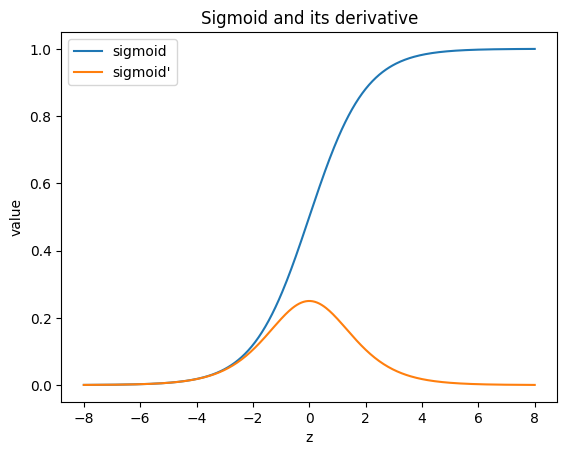

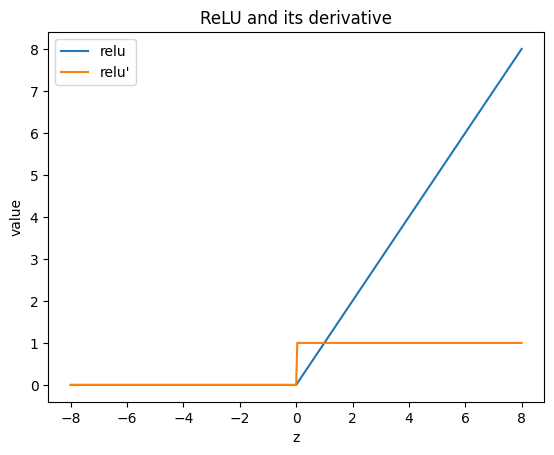

In [47]:
plt.figure()
plt.plot(zs, sig, label="sigmoid")
plt.plot(zs, dsig, label="sigmoid'")
plt.legend()
plt.title("Sigmoid and its derivative")
plt.xlabel("z")
plt.ylabel("value")
plt.show()

plt.figure()
plt.plot(zs, r, label="relu")
plt.plot(zs, dr, label="relu'")
plt.legend()
plt.title("ReLU and its derivative")
plt.xlabel("z")
plt.ylabel("value")
plt.show()


## 4) Loss functions (scalar objectives)

A **loss** is a single number that tells you how wrong the model is.

Two common ones:
- **MSE** for regression: `L = 0.5 (ŷ - y)^2`
- **Binary cross-entropy** for classification: `L = -[y log(ŷ) + (1-y) log(1-ŷ)]`

For Phase 1, we’ll use **MSE** because the derivatives are super clean.


In [48]:
def mse_loss(y_hat, y):
    return 0.5 * (y_hat - y)**2


In [49]:
y_hat = 0.7
y = 1.0
print("MSE loss:", mse_loss(y_hat, y))

MSE loss: 0.04500000000000001


## 5) Chain rule: the entire secret of backprop

If `L` depends on `a`, and `a` depends on `z`, then:

`dL/dz = (dL/da) * (da/dz)`

Backprop is just applying this repeatedly through the computation graph.


### A simple computation graph

Let:
- `z = w·x + b`
- `a = σ(z)`
- `L = 0.5 (a - y)^2`

We will compute gradients **by hand**:
- `dL/dw`
- `dL/db`

This is the core you must own.


In [50]:
def forward(w, b, x):
    z = w @ x + b
    a = sigmoid(z)
    return z, a

def loss_mse(a, y):
    return 0.5 * (a - y)**2

# One data point
x = np.array([1.5, 0.2, -0.3])
y = 1.0

# Parameters
w = np.array([0.5, -1.0, 2.0])
b = -0.1

z, a = forward(w, b, x)
L = loss_mse(a, y)

print("z:", z)
print("a = sigmoid(z):", a)
print("L:", L)


z: -0.14999999999999994
a = sigmoid(z): 0.46257015465625045
L: 0.1444154193331033


## 6) Manual derivatives for the single neuron

We compute step-by-step:

1) `dL/da = (a - y)`

2) `da/dz = a(1-a)` because `a = sigmoid(z)`

3) `dz/dw = x` and `dz/db = 1` because `z = w·x + b`

Combine with chain rule:

`dL/dz = (a - y) * a(1-a)`

`dL/dw = dL/dz * x`

`dL/db = dL/dz`


In [51]:
# Manual gradients
dL_da = (a - y)                 # derivative of 0.5(a-y)^2 wrt a
da_dz = a * (1.0 - a)           # sigmoid derivative
dL_dz = dL_da * da_dz

dL_dw = dL_dz * x               # elementwise multiply: each w_i gets x_i scaled by dL/dz
dL_db = dL_dz

print("dL/da:", dL_da)
print("da/dz:", da_dz)
print("dL/dz:", dL_dz)
print("dL/dw:", dL_dw)
print("dL/db:", dL_db)


dL/da: -0.5374298453437496
da/dz: 0.248599006677543
dL/dz: -0.13360452571132173
dL/dw: [-0.2004 -0.0267  0.0401]
dL/db: -0.13360452571132173


### Interpret the signs (this is the intuition)

- If `dL/dw_i` is **positive**, decreasing `w_i` decreases loss.
- If `dL/dw_i` is **negative**, increasing `w_i` decreases loss.

In gradient descent: `w := w - lr * dL/dw`.


In [52]:
lr = 0.5
w_new = w - lr * dL_dw
b_new = b - lr * dL_db

z2, a2 = forward(w_new, b_new, x)
L2 = loss_mse(a2, y)

print("Old L:", float(L))
print("New L:", float(L2))
print("L(delta):", float(L2 - L))


Old L: 0.1444154193331033
New L: 0.11570991646481482
L(delta): -0.02870550286828849


## 7) Numerical gradient check (sanity check)

We approximate gradients by finite differences and compare with the manual ones.

If these match, your chain rule math is correct.


In [54]:
def loss_given_params(w, b, x, y):
    z = w @ x + b
    a = sigmoid(z)
    return float(0.5 * (a - y)**2)

def numerical_grad_w(w, b, x, y, eps=1e-6):
    g = np.zeros_like(w, dtype=float)
    base = loss_given_params(w, b, x, y)
    for i in range(len(w)):
        w2 = w.copy()
        w2[i] += eps
        g[i] = (loss_given_params(w2, b, x, y) - base) / eps
    return g

def numerical_grad_b(w, b, x, y, eps=1e-6):
    base = loss_given_params(w, b, x, y)
    return (loss_given_params(w, b + eps, x, y) - base) / eps

g_num_w = numerical_grad_w(w, b, x, y)
g_num_b = numerical_grad_b(w, b, x, y)

print("Manual dL/dw:", dL_dw)
print("Numeric dL/dw:", g_num_w)
print("Abs diff:", np.abs(dL_dw - g_num_w))

print("\nManual dL/db:", dL_db)
print("Numeric dL/db:", g_num_b)
print("Abs diff:", abs(dL_db - g_num_b))


Manual dL/dw: [-0.2004 -0.0267  0.0401]
Numeric dL/dw: [-0.2004 -0.0267  0.0401]
Abs diff: [0. 0. 0.]

Manual dL/db: -0.13360452571132173
Numeric dL/db: -0.13360449985233558
Abs diff: 2.5858986146820584e-08


## 8) Visualize loss vs a single weight

This helps you see what gradient descent is doing: it’s moving downhill on a loss curve.


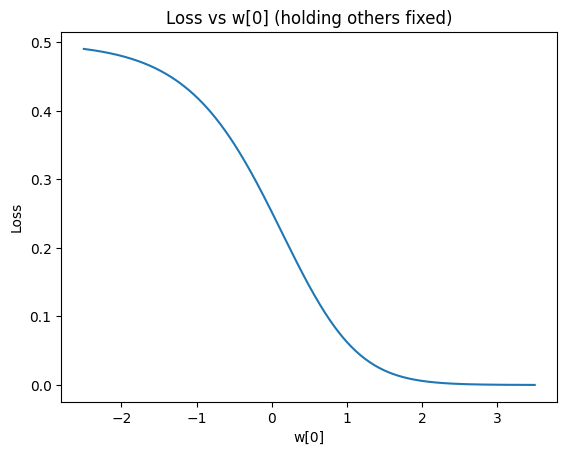

Current w[i]: 0.5 Current loss: 0.1444154193331033
Gradient dL/dw[i]: -0.20040678856698257


In [55]:
i = 0  # choose which weight to vary
ws = np.linspace(w[i]-3, w[i]+3, 400)

Ls = []
for wi in ws:
    wtmp = w.copy()
    wtmp[i] = wi
    Ls.append(loss_given_params(wtmp, b, x, y))

plt.figure()
plt.plot(ws, Ls)
plt.title(f"Loss vs w[{i}] (holding others fixed)")
plt.xlabel(f"w[{i}]")
plt.ylabel("Loss")
plt.show()

print("Current w[i]:", w[i], "Current loss:", loss_given_params(w, b, x, y))
print("Gradient dL/dw[i]:", dL_dw[i])


## What you should be able to say out loud after this notebook

- A neuron is a dot product + bias + nonlinearity.
- Backprop is chain rule.
- `dL/dw` points in the direction of increasing loss; subtract it to decrease loss.
- Sigmoid can saturate: when `a≈0` or `a≈1`, `a(1-a)` is tiny → vanishing gradients.
